2023-08-15 16:47:04,354 - pegasusio.readwrite - INFO - 10x file '../LBP_brain_blood_pairs/data/narsad_cellRanger_outs/blood/PT-214-blood-R/PT-214-R-B_CellBender_filtered.h5' is loaded.
2023-08-15 16:47:04,355 - pegasusio.readwrite - INFO - Function 'read_input' finished in 0.38s.
2023-08-15 16:47:04,504 - pegasusio.qc_utils - INFO - After filtration, 3604 out of 3762 cell barcodes are kept in UnimodalData object GRCh38-rna.
2023-08-15 16:47:04,504 - pegasus.tools.preprocessing - INFO - Function 'filter_data' finished in 0.10s.
2023-08-15 16:47:04,651 - pegasusio.qc_utils - INFO - After filtration, 3604 out of 3604 cell barcodes are kept in UnimodalData object GRCh38-rna.
2023-08-15 16:47:04,652 - pegasus.tools.preprocessing - INFO - Function 'filter_data' finished in 0.09s.
2023-08-15 16:47:04,777 - pegasus.tools.preprocessing - INFO - After filtration, 21176/36601 genes are kept. Among 21176 genes, 18834 genes are robust.
2023-08-15 16:47:04,777 - pegasus.tools.preprocessing - INFO - 

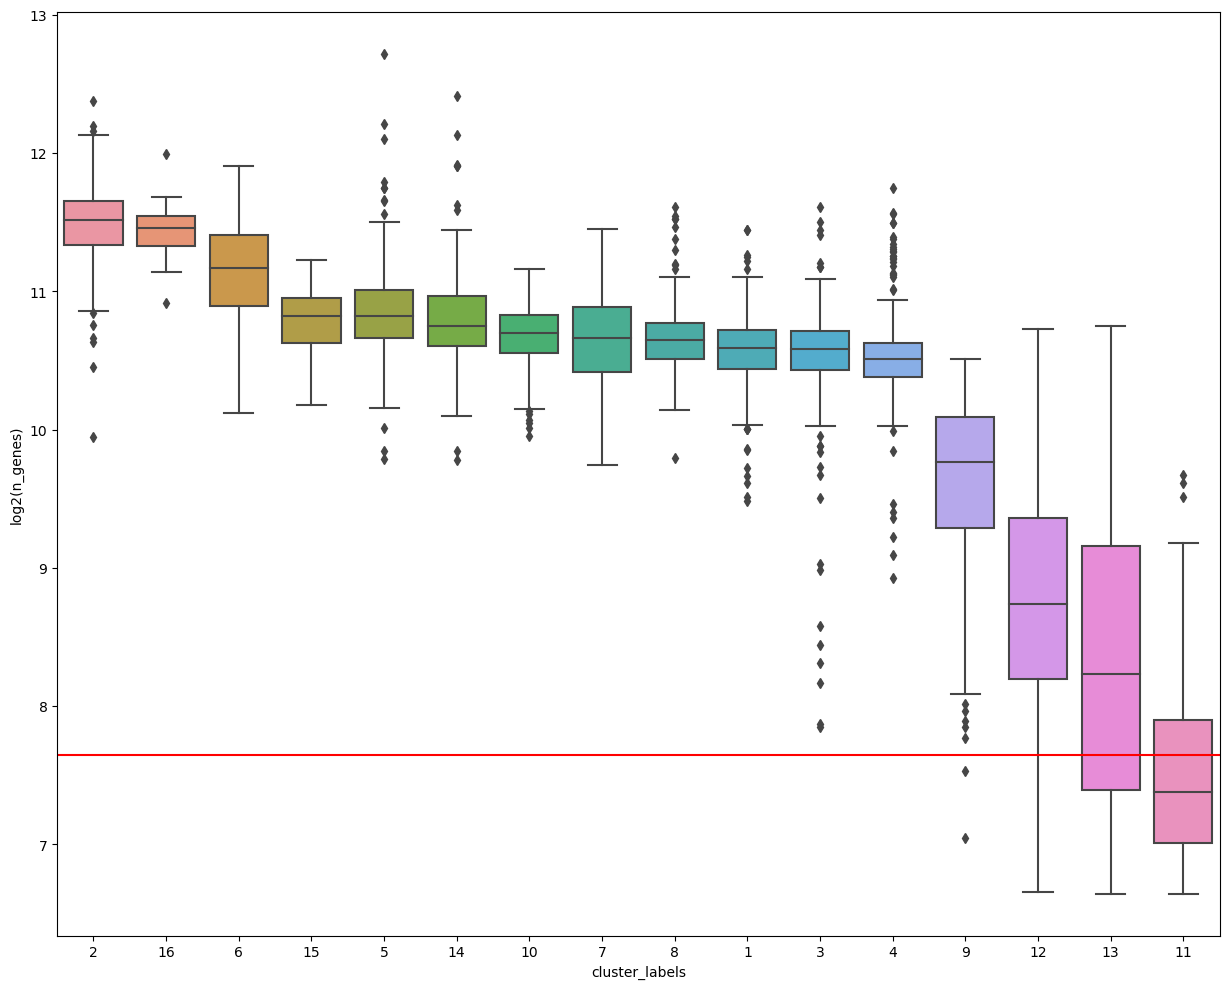

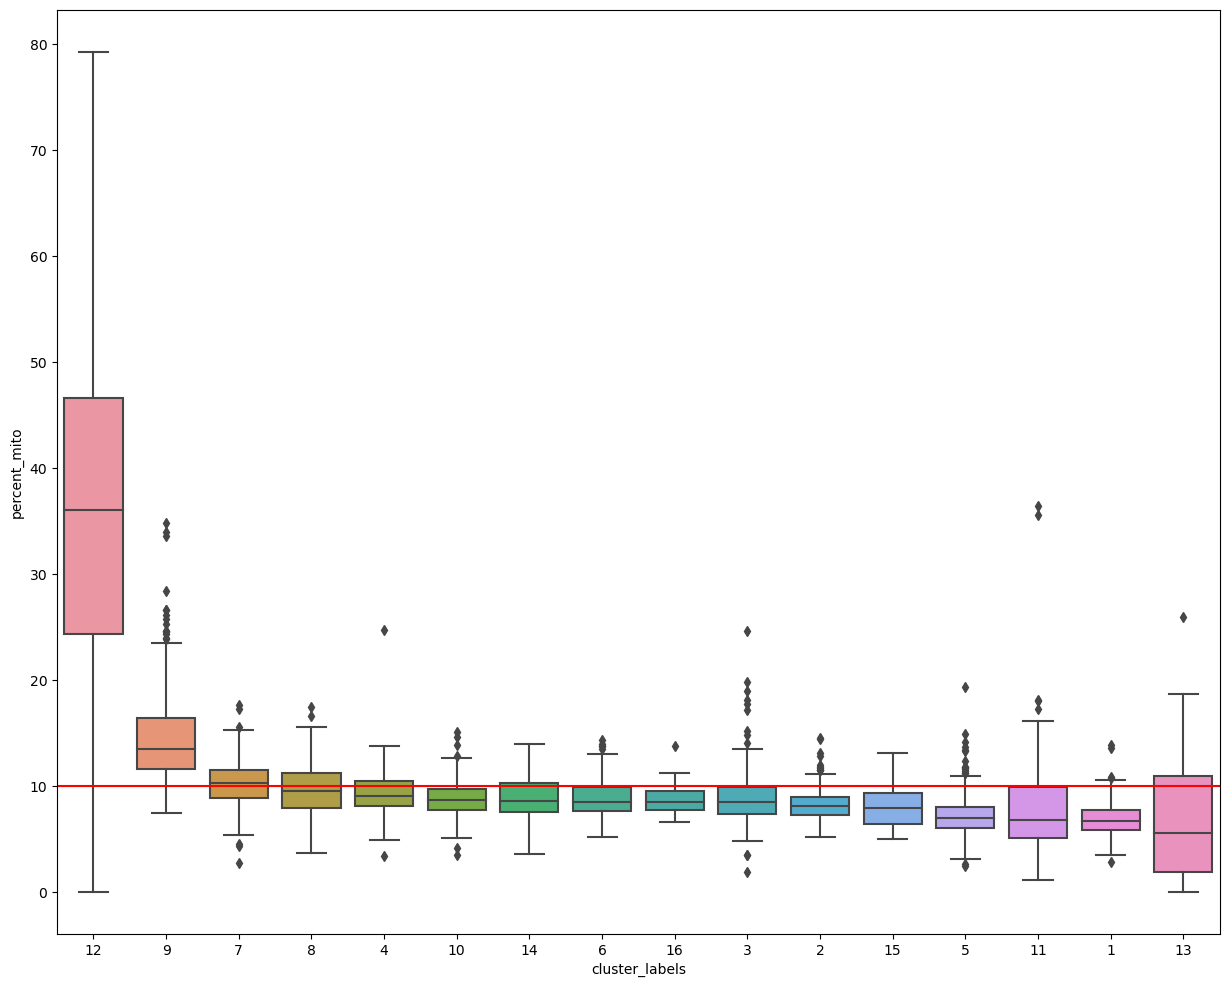

/Users/nicolebussola/anaconda3/envs/ddqc/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/Users/nicolebussola/anaconda3/envs/ddqc/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


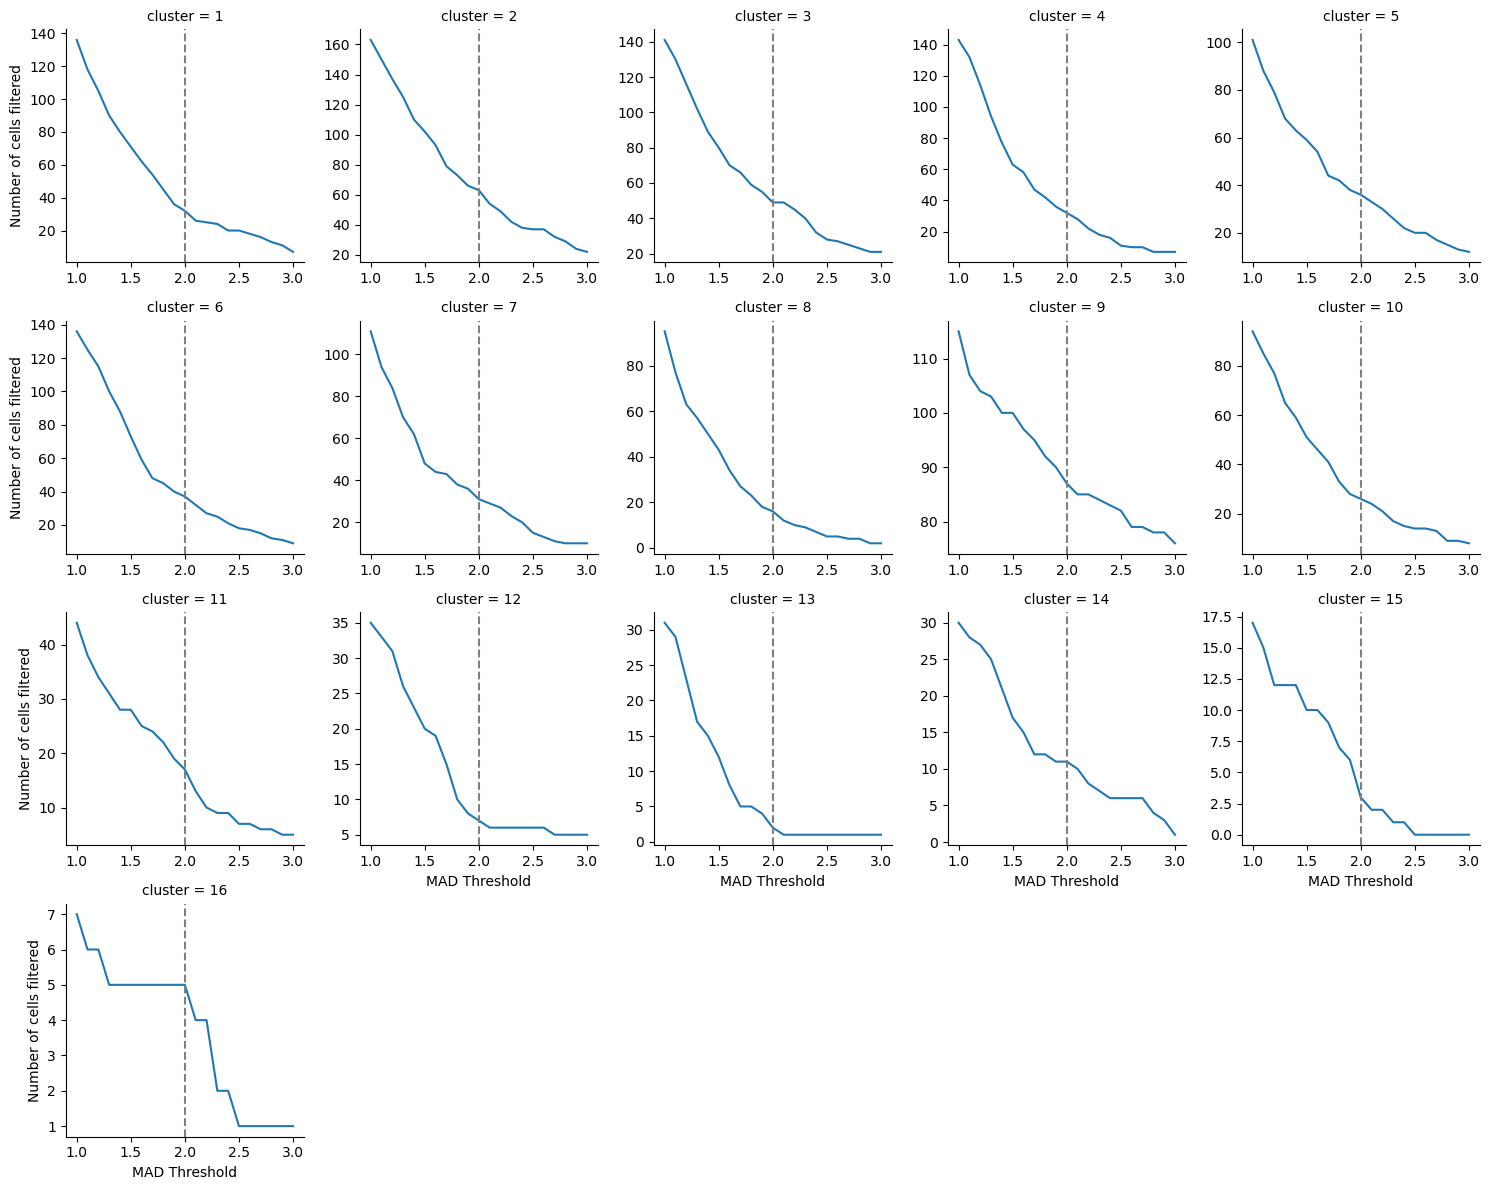

/Users/nicolebussola/anaconda3/envs/ddqc/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/Users/nicolebussola/anaconda3/envs/ddqc/lib/python3.8/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


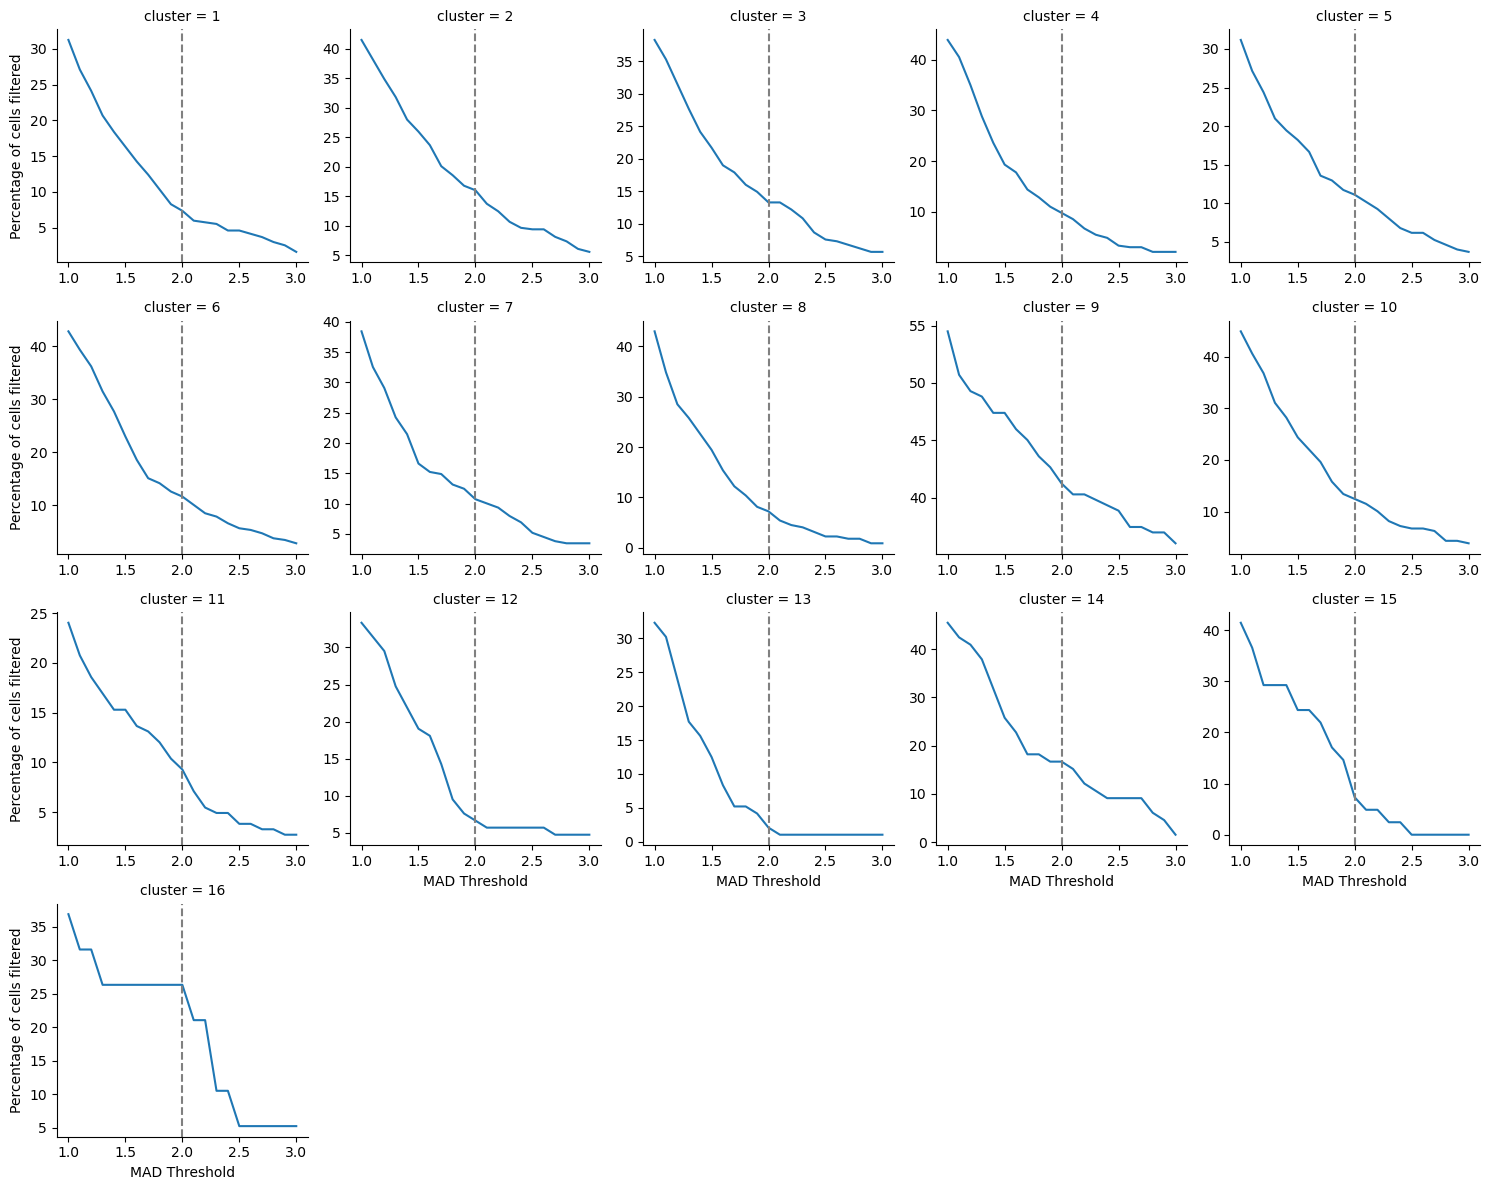

(3604, 36601)
2023-08-15 16:47:12,846 - pegasusio.qc_utils - INFO - After filtration, 3150 out of 3604 cell barcodes are kept in UnimodalData object GRCh38-rna.
2023-08-15 16:47:12,847 - pegasus.tools.preprocessing - INFO - Function 'filter_data' finished in 0.14s.


In [7]:
import pegasusio as io
import pegasus as pg

import ddqc
# read h5
adata = io.read_input("../LBP_brain_blood_pairs/data/narsad_cellRanger_outs/blood/PT-214-blood-R/PT-214-R-B_CellBender_filtered.h5", genome = 'hg38')
data_qc = ddqc.ddqc_metrics(adata, return_df_qc=True, display_plots=True)
print(adata.shape)
pg.filter_data(adata)


2023-08-15 16:46:09,581 - pegasus.tools.preprocessing - INFO - After filtration, 20857/36601 genes are kept. Among 20857 genes, 18523 genes are robust.
2023-08-15 16:46:09,581 - pegasus.tools.preprocessing - INFO - Function 'identify_robust_genes' finished in 0.11s.
2023-08-15 16:46:09,644 - pegasus.tools.preprocessing - INFO - Function 'log_norm' finished in 0.06s.
2023-08-15 16:46:09,657 - pegasus.tools.hvf_selection - INFO - Function 'estimate_feature_statistics' finished in 0.01s.
2023-08-15 16:46:09,716 - pegasus.tools.hvf_selection - INFO - 2000 highly variable features have been selected.
2023-08-15 16:46:09,716 - pegasus.tools.hvf_selection - INFO - Function 'highly_variable_features' finished in 0.07s.


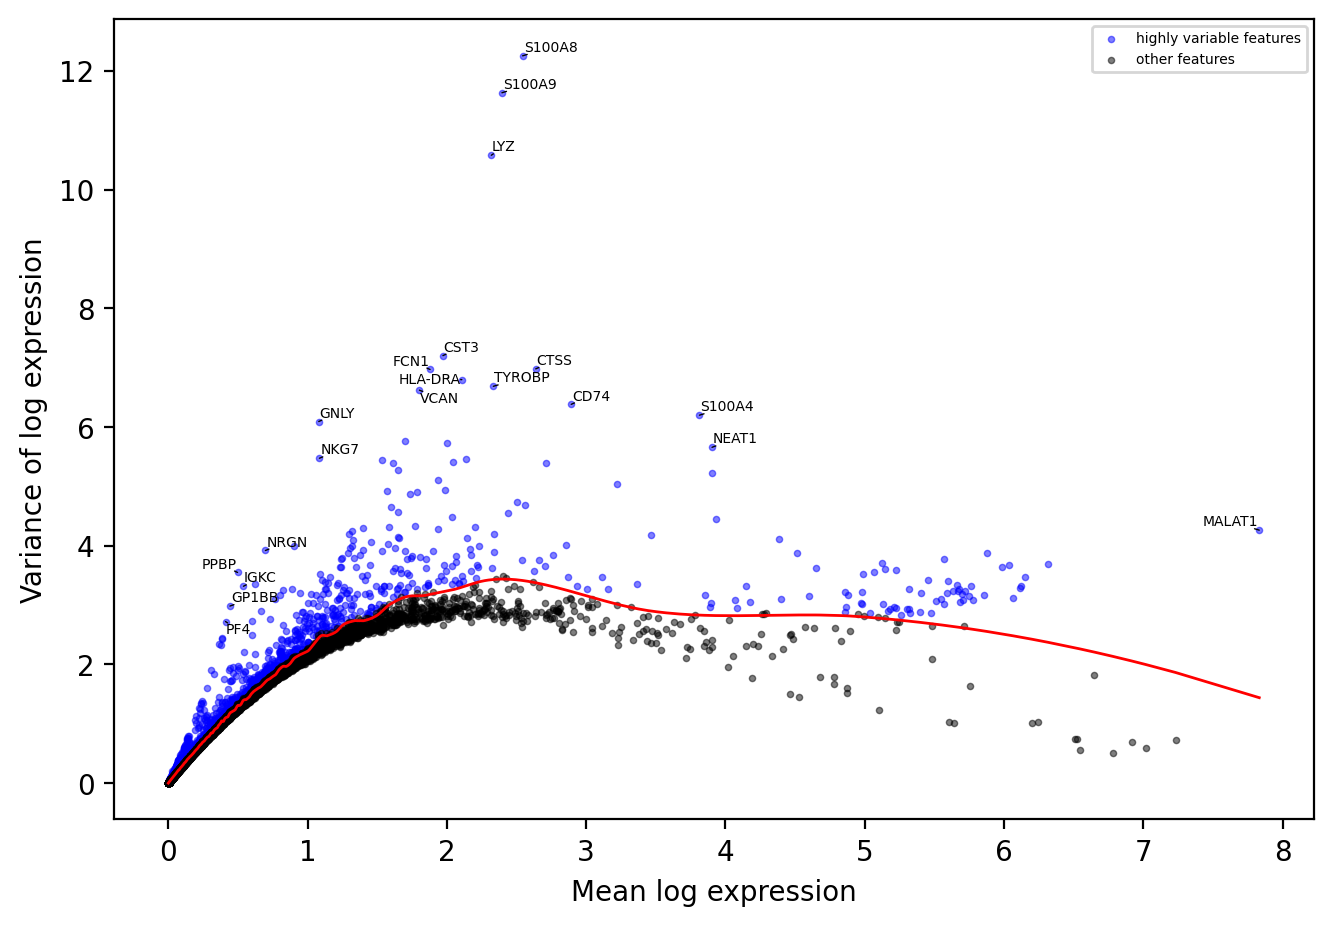

In [2]:

data_trial = adata.copy()
pg.identify_robust_genes(data_trial)

pg.log_norm(data_trial)
pg.highly_variable_features(data_trial)
pg.hvfplot(data_trial, dpi=200)


In [3]:
pg.pca(data_trial)
pg.neighbors(data_trial)
pg.umap(data_trial, rep="pca")


2023-08-15 16:46:15,836 - pegasus.tools.preprocessing - INFO - Function 'pca' finished in 0.59s.
2023-08-15 16:46:16,105 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 0.27s.
2023-08-15 16:46:16,174 - pegasus.tools.nearest_neighbors - INFO - Function 'calculate_affinity_matrix' finished in 0.07s.
2023-08-15 16:46:16,174 - pegasus.tools.nearest_neighbors - INFO - Found cached kNN results, no calculation is required.
2023-08-15 16:46:16,175 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 0.00s.
2023-08-15 16:46:16,176 - pegasus.tools.visualization - INFO - Using umap kNN graph because number of cells 3150 is smaller than 4096 or knn_indices is not provided.
UMAP(min_dist=0.5, random_state=0, verbose=True)
Tue Aug 15 16:46:16 2023 Construct fuzzy simplicial set
Tue Aug 15 16:46:19 2023 Finding Nearest Neighbors
Tue Aug 15 16:46:20 2023 Finished Nearest Neighbor Search
Tue Aug 15 16:46:22 2023 Construct embedding


Epochs completed: 100%| █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████ 500/500 [00:04]

Tue Aug 15 16:46:27 2023 Finished embedding
2023-08-15 16:46:27,330 - pegasus.tools.visualization - INFO - Function 'umap' finished in 11.16s.


In [4]:
data_trial

MultimodalData object with 1 UnimodalData: 'GRCh38-rna'
    It currently binds to UnimodalData object GRCh38-rna

UnimodalData object with n_obs x n_vars = 3150 x 20857
    UID: GRCh38-rna; Genome: GRCh38; Modality: rna
    It contains 2 matrices: 'counts', 'counts.log_norm'
    It currently binds to matrix 'counts.log_norm' as X

    obs: 'n_genes', 'n_counts', 'percent_mito', 'percent_ribo', 'scale'
    var: 'featureid', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'mean', 'var', 'hvf_loess', 'hvf_rank'
    obsm: 'X_pca', 'pca_knn_indices'(knn), 'pca_knn_distances'(knn), 'X_umap'(basis)
    obsp: 'W_pca'
    uns: 'genome', 'modality', 'uid', 'norm_count', 'stdzn_mean', 'stdzn_std', 'stdzn_max_value', '_tmp_fmat_highly_variable_features', 'PCs', 'pca', 'pca_features', '_attr2type'

In [5]:
data_trial.obs = data_qc

IndexError: boolean index did not match indexed array along dimension 0; dimension is 3150 but corresponding boolean dimension is 3604

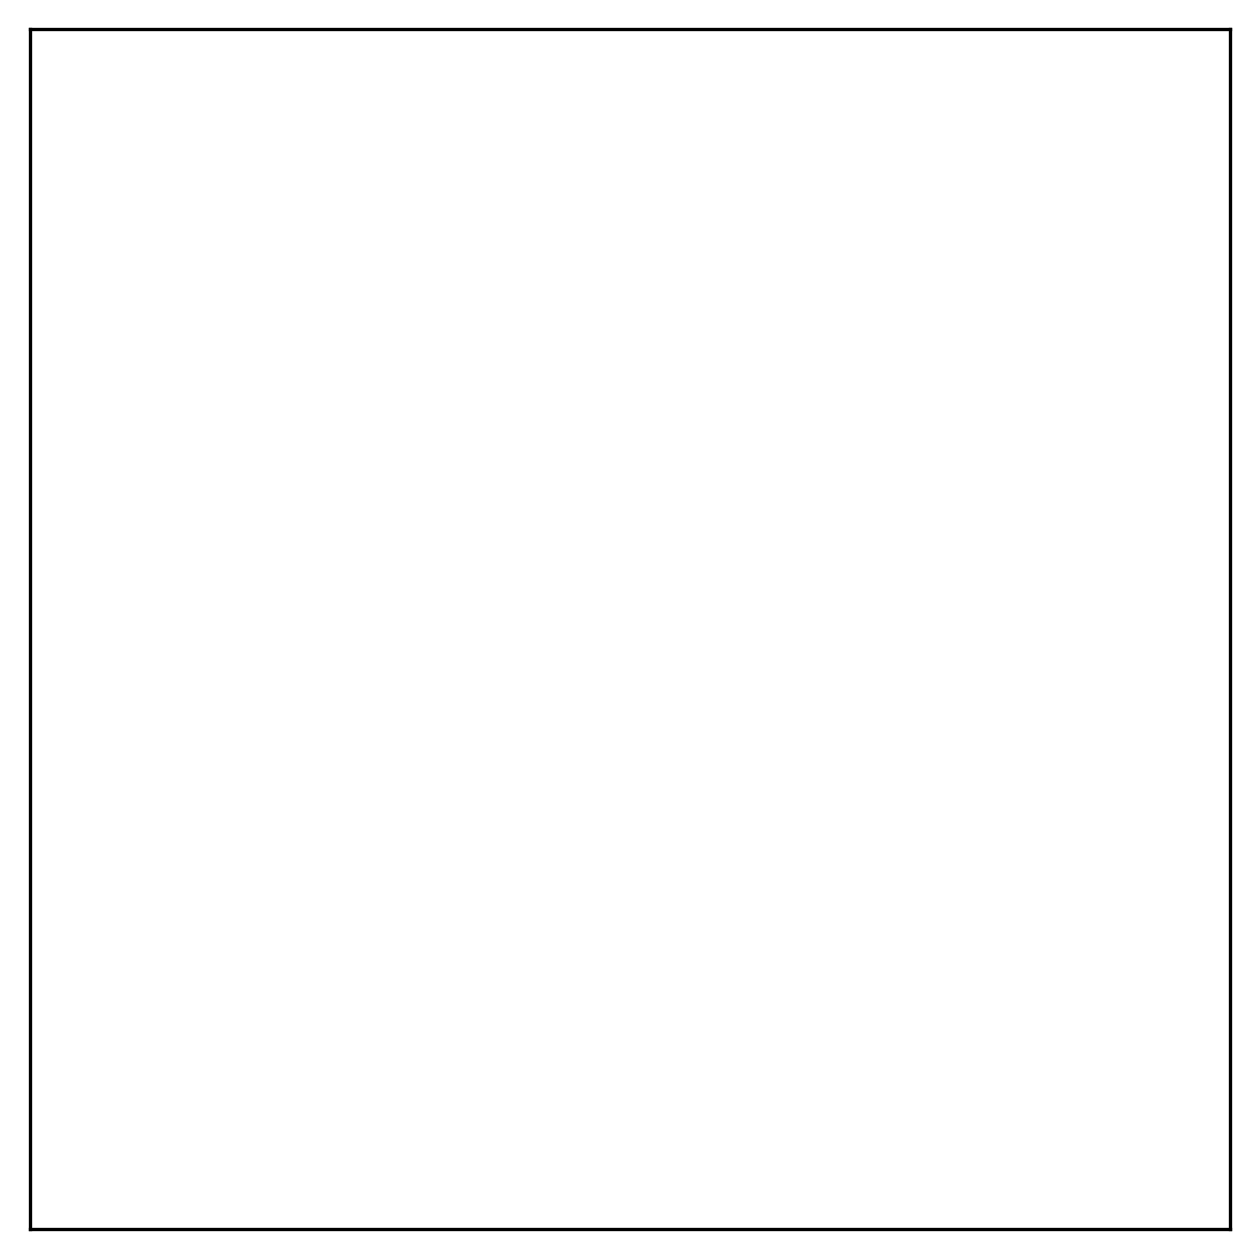

In [6]:
pg.scatter(data_trial, attrs="passed_qc")


In [ ]:

pg.scatter(data_trial, attrs="cluster_labels")


In [10]:
data_trial.obs.shape[0],data_trial.obs['passed_qc'].sum()

(2790, 2501)

In [11]:
adata.shape

(2790, 36601)

In [13]:
pg.filter_data(data_trial)


2023-08-15 10:37:06,315 - pegasusio.qc_utils - INFO - After filtration, 2501 out of 2790 cell barcodes are kept in UnimodalData object GRCh38-rna.
2023-08-15 10:37:06,316 - pegasus.tools.preprocessing - INFO - Function 'filter_data' finished in 0.14s.


In [15]:
data_trial

MultimodalData object with 1 UnimodalData: 'GRCh38-rna'
    It currently binds to UnimodalData object GRCh38-rna

UnimodalData object with n_obs x n_vars = 2790 x 21749
    UID: GRCh38-rna; Genome: GRCh38; Modality: rna
    It contains 2 matrices: 'counts', 'counts.log_norm'
    It currently binds to matrix 'counts.log_norm' as X

    obs: 'cluster_labels', 'n_counts_lower_co', 'n_counts_upper_co', 'n_counts', 'n_counts_passed_qc', 'n_genes_lower_co', 'n_genes_upper_co', 'n_genes', 'n_genes_passed_qc', 'percent_mito_lower_co', 'percent_mito_upper_co', 'percent_mito', 'percent_mito_passed_qc', 'percent_ribo_lower_co', 'percent_ribo_upper_co', 'percent_ribo', 'percent_ribo_passed_qc', 'passed_qc'
    var: 'featureid', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'mean', 'var', 'hvf_loess', 'hvf_rank'
    obsm: 'X_pca', 'pca_knn_indices'(knn), 'pca_knn_distances'(knn), 'X_umap'(basis)
    obsp: 'W_pca'
    uns: 'genome', 'modality', 'uid', 'norm_count', 'stdzn_mean', 